In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [301]:
df = pd.read_csv('/content/ec2_cpu_utilization_24ae8d.csv')
df.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


In [302]:
anomaly_timestamps = [
    "2014-02-26 22:05:00",
    "2014-02-27 17:15:00"
]

In [303]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [304]:
df["is anomaly"] = 1
df.loc[
    df["timestamp"].isin(pd.to_datetime(anomaly_timestamps)),
    "is anomaly"
] = -1

**Visualization**

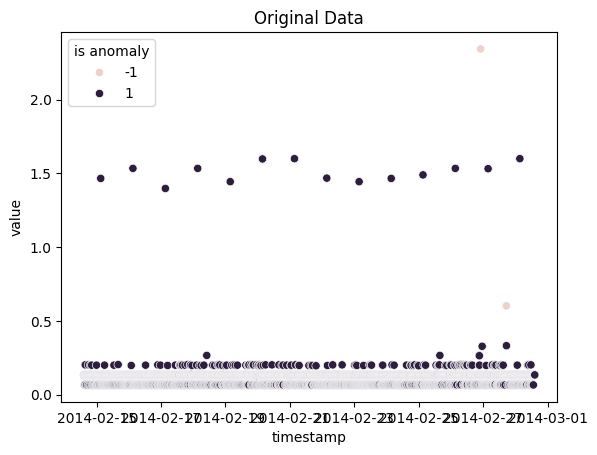

In [305]:
sns.scatterplot(
    data=df,
    x="timestamp",
    y="value",

   hue = "is anomaly"
)

plt.title("Original Data")
plt.show()

**Isolation Forest Model**

In [306]:
x = df[["value"]]
model = IsolationForest(
    contamination=0.05,
    random_state=42
)
model.fit(x)
df["Isolation_Forest"] = model.predict(x)

**Visualization**

In [307]:
df["Prediction"] = df["Isolation_Forest"].map({
    1: "Normal",
    -1: "Anomaly"
})

In [308]:
df.head()

,timestamp,value,is anomaly,Isolation_Forest,Prediction
0,2014-02-14 14:30:00,0.132,1,1,Normal
1,2014-02-14 14:35:00,0.134,1,1,Normal
2,2014-02-14 14:40:00,0.134,1,1,Normal
3,2014-02-14 14:45:00,0.134,1,1,Normal
4,2014-02-14 14:50:00,0.134,1,1,Normal


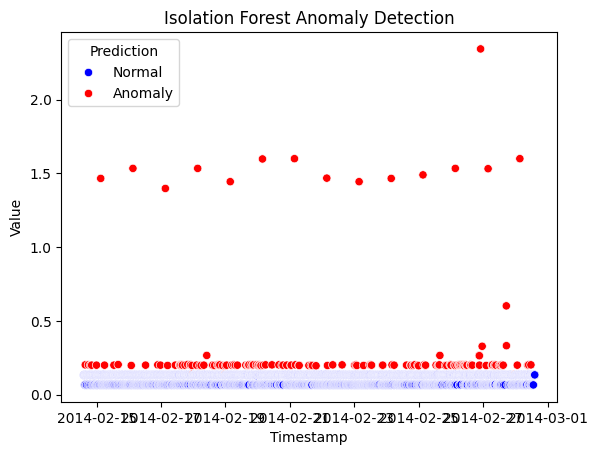

In [309]:
sns.scatterplot(
    data = df,
    x = 'timestamp',
    y = 'value',
    hue = "Prediction",
    palette={
        "Normal": "blue",
        "Anomaly": "red"
    }
)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend(title="Prediction")
plt.show()

**Confusion matrix**

In [312]:
def plot_confusion_matrix(y_true, y_pred, title):
  cm = confusion_matrix(y_true, y_pred,
      labels=[1, -1]
  )


  disp = ConfusionMatrixDisplay(
      confusion_matrix = cm,
      display_labels = ["Normal", "Anomaly"]

  )
  disp.plot()
  plt.title(title)
  plt.show()

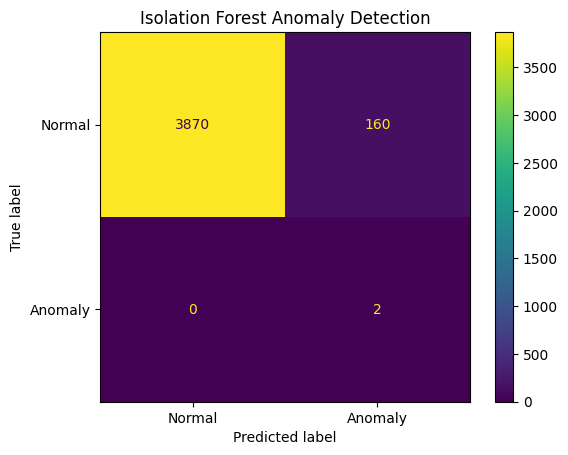

In [313]:
plot_confusion_matrix(
    df["is anomaly"],
    df["Isolation_Forest"],
    "Isolation Forest Anomaly Detection"
)